<a href="https://colab.research.google.com/github/VincentStimper/normalizing-flows/blob/master/examples/real_nvp_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Illustration of the Usage of the `normflows` Package
## Training a Real NVP model

This notebook illustrates how to use the `normflows` packages by training a simple [Real NVP](https://arxiv.org/abs/1605.08803) model to a 2D distribution consisting on two half moons.

Before we can start, we have to install the package.

In [4]:
# Import required packages
import torch
import numpy as np
import normflows as nf

from matplotlib import pyplot as plt

from tqdm import tqdm

After importing the required packages, we want to create a `nf.NormalizingFlow` model. Therefore, we need a base distribution, which we set to be a Gaussian, and a list of flow layers. The flow layers are simply affine coupling layers, whereby `nf.AffineCouplingBlock` already includes the splitting and merging of the features as it is done in coupling. We also swap the features after each layer to ensure that they are all modified.

In [5]:
nf.nets.MLP

normflows.nets.mlp.MLP

In [6]:
# Set up model

# Define 2D Gaussian base distribution
base = nf.distributions.base.DiagGaussian(2)

# Define list of flows
num_layers = 32
flows = []
for i in range(num_layers):
    # Neural network with two hidden layers having 64 units each
    # Last layer is initialized by zeros making training more stable
    param_map = nf.nets.MLP([1, 64, 64, 2], init_zeros=True)
    # Add flow layer
    flows.append(nf.flows.AffineCouplingBlock(param_map))
    # Swap dimensions
    flows.append(nf.flows.Permute(2, mode='swap'))
    
# Construct flow model
model = nf.NormalizingFlow(base, flows)

In [7]:
# Move model on GPU if available
enable_cuda = True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')
model = model.to(device)

This is our target distribution.

In [8]:
# Define target distribution
target = nf.distributions.TwoMoons()

/Users/leo/miniconda3/envs/venv_pytorch/lib/python3.14/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/ec2-user/croot/libtorch_1780519564378/work/aten/src/ATen/native/TensorShape.cpp:4384.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


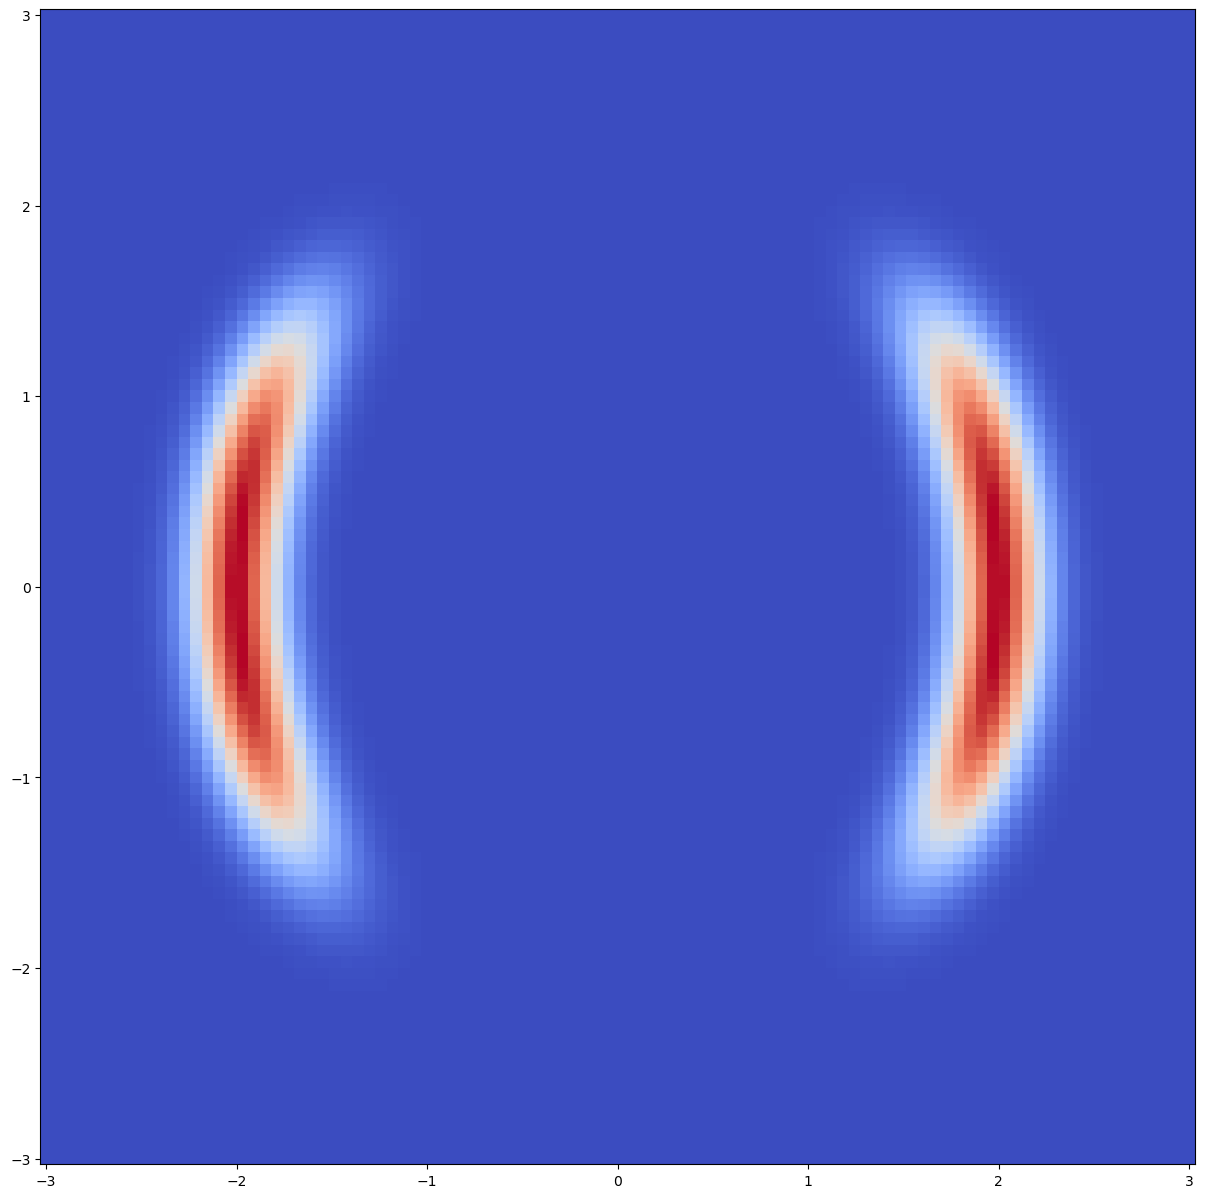

In [9]:
# Plot target distribution
grid_size = 100
xx, yy = torch.meshgrid(torch.linspace(-3, 3, grid_size), torch.linspace(-3, 3, grid_size))
zz = torch.cat([xx.unsqueeze(2), yy.unsqueeze(2)], 2).view(-1, 2)
zz = zz.to(device)
zz.requires_grad_(True)

log_prob = target.log_prob(zz).to('cpu').view(*xx.shape)
prob = torch.exp(log_prob)
prob[torch.isnan(prob)] = 0

plt.figure(figsize=(15, 15))
plt.pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')
plt.gca().set_aspect('equal', 'box')
plt.show()

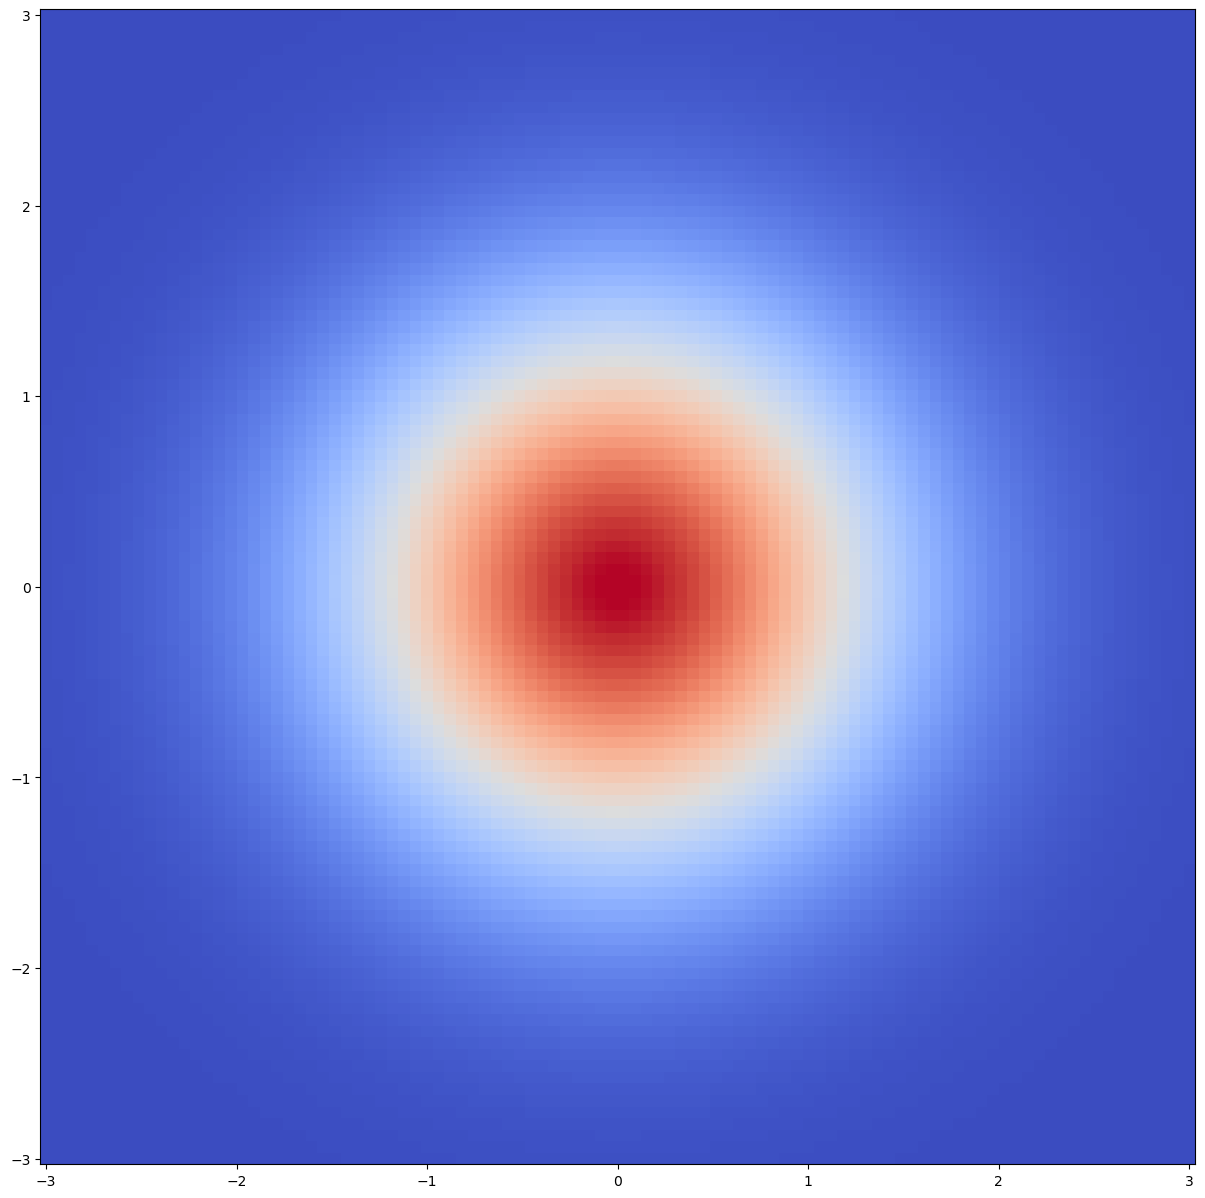

In [10]:
# Plot initial flow distribution
model.eval()
log_prob = model.log_prob(zz).to('cpu').view(*xx.shape)
model.train()
prob = torch.exp(log_prob)
prob[torch.isnan(prob)] = 0

plt.figure(figsize=(15, 15))
plt.pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')
plt.gca().set_aspect('equal', 'box')
plt.show()

Now, we are ready to train the flow model. This can be done in a similar fashion as standard neural networks. Since we use samples from the target for training, we use the forward KL divergence as objective, which is equivalent to maximum likelihood.

In [11]:
model

NormalizingFlow(
  (q0): DiagGaussian()
  (flows): ModuleList(
    (0): AffineCouplingBlock(
      (flows): ModuleList(
        (0): Split()
        (1): AffineCoupling(
          (param_map): MLP(
            (net): Sequential(
              (0): Linear(in_features=1, out_features=64, bias=True)
              (1): LeakyReLU(negative_slope=0.0)
              (2): Linear(in_features=64, out_features=64, bias=True)
              (3): LeakyReLU(negative_slope=0.0)
              (4): Linear(in_features=64, out_features=2, bias=True)
            )
          )
        )
        (2): Merge()
      )
    )
    (1): Permute()
    (2): AffineCouplingBlock(
      (flows): ModuleList(
        (0): Split()
        (1): AffineCoupling(
          (param_map): MLP(
            (net): Sequential(
              (0): Linear(in_features=1, out_features=64, bias=True)
              (1): LeakyReLU(negative_slope=0.0)
              (2): Linear(in_features=64, out_features=64, bias=True)
              (3): Le

In [13]:
target_sample = target.sample(100)

In [1]:
# Train model
max_iter = 4000
num_samples = 2 ** 9
show_iter = 500


loss_hist = np.array([])

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)

for it in tqdm(range(max_iter)):
    optimizer.zero_grad()
    
    
    # Get training samples
    x = target.sample(num_samples).to(device)
    
    # Compute loss
    loss = model.forward_kld(x)
    print(loss)
    
    # Do backprop and optimizer step
    if ~(torch.isnan(loss) | torch.isinf(loss)):
        loss.backward()
        optimizer.step()
    
    # Log loss
    loss_hist = np.append(loss_hist, loss.to('cpu').data.numpy())
    
    # Plot learned distribution
    if (it + 1) % show_iter == 0:
        model.eval()
        log_prob = model.log_prob(zz)
        model.train()
        prob = torch.exp(log_prob.to('cpu').view(*xx.shape))
        prob[torch.isnan(prob)] = 0

        plt.figure(figsize=(15, 15))
        plt.pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')
        plt.gca().set_aspect('equal', 'box')
        plt.show()

# Plot loss
plt.figure(figsize=(10, 10))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()

NameError: name 'np' is not defined

This is our trained flow model!

Note that there might be a density filament connecting the two modes, which is due to an architectural limitation of normalizing flows, especially prominent in Real NVP. You can find out more about it in [this paper](https://proceedings.mlr.press/v151/stimper22a).

In [221]:
prob_model.shape

torch.Size([100, 100])

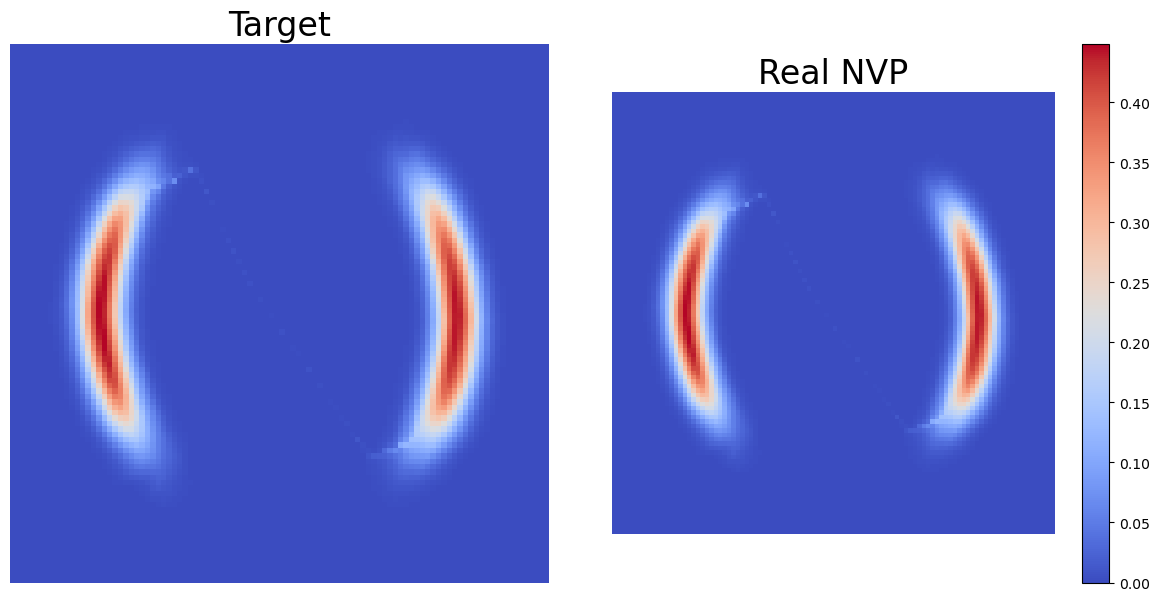

In [222]:
# Plot target distribution
f, ax = plt.subplots(1, 2, sharey=True, figsize=(15, 7))

log_prob = target.log_prob(zz).to('cpu').view(*xx.shape)
log_prob_target = target.log_prob(zz).to('cpu')
prob_target = torch.exp(log_prob)
prob[torch.isnan(prob)] = 0



ax[0].pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')

ax[0].set_aspect('equal', 'box')
ax[0].set_axis_off()
ax[0].set_title('Target', fontsize=24)

# Plot learned distribution
model.eval()
log_prob = model.log_prob(zz).to('cpu').view(*xx.shape)
log_prob_model = model.log_prob(zz).to('cpu')
prob_model = torch.exp(log_prob)
#prob_model[torch.isnan(prob_model)] = 0
model.train()
prob = torch.exp(log_prob)
prob[torch.isnan(prob)] = 0

im1 = ax[1].pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')

ax[1].set_aspect('equal', 'box')
ax[1].set_axis_off()
ax[1].set_title('Real NVP', fontsize=24)
plt.colorbar(im1)

plt.subplots_adjust(wspace=0.1)

plt.show()


target_to_model_normalization = torch.sum(prob_target) / torch.nansum(prob_model)

In [223]:
target_to_model_normalization

tensor(2.2352, grad_fn=<DivBackward0>)

In [224]:
zz

tensor([[-3.0000, -3.0000],
        [-3.0000, -2.9394],
        [-3.0000, -2.8788],
        ...,
        [ 3.0000,  2.8788],
        [ 3.0000,  2.9394],
        [ 3.0000,  3.0000]], requires_grad=True)

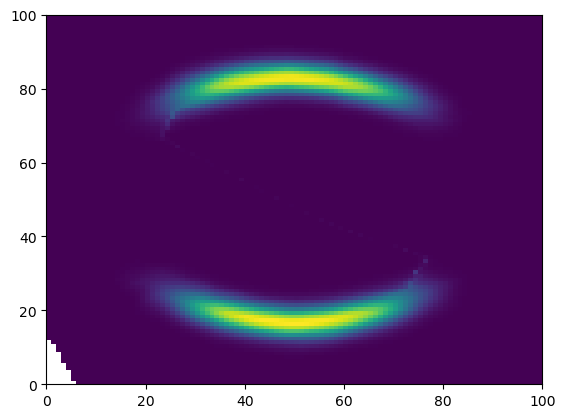

In [225]:
plt.pcolor(prob_model.detach().numpy())

In [226]:
zz

tensor([[-3.0000, -3.0000],
        [-3.0000, -2.9394],
        [-3.0000, -2.8788],
        ...,
        [ 3.0000,  2.8788],
        [ 3.0000,  2.9394],
        [ 3.0000,  3.0000]], requires_grad=True)

In [227]:
grad_autograd = torch.full((prob_model.shape[0], prob_model.shape[1], 2), torch.nan)
counter = 0
for i in range(prob_model.shape[0]):
    for j in range(prob_model.shape[1]):
        if (prob_model[i, j] is not torch.nan) | (prob_model[i, j] is not torch.inf):
            grad_autograd[i,j,:] = torch.autograd.grad(prob_model[i, j], zz, retain_graph=True)[0][counter, :]
        print(counter)
        counter += 1


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [228]:
zz.shape

torch.Size([10000, 2])

In [229]:
zz_perturb_positive = zz.clone().detach()

zz_perturb_positive = zz_perturb_positive[100, :]
zz_perturb_positive[1] += 0.01

In [230]:
step = 1e-5

grad_fd = torch.full((prob_model.shape[0], prob_model.shape[1], 2), torch.nan)
counter = 0
for i in range(prob_model.shape[0]):
    for j in range(prob_model.shape[1]):
        for k in range(2):
            if (prob_model[i, j] is not torch.nan) | (prob_model[i, j] is not torch.inf):

                zz_perturb_positive = zz.clone().detach()
                zz_perturb_positive = zz_perturb_positive[counter:counter+1, :]
                zz_perturb_positive[0, k] += step

                zz_perturb_negative = zz.clone().detach()
                zz_perturb_negative = zz_perturb_negative[counter:counter+1, :]
                zz_perturb_negative[0, k] -= step

                log_prob_model_positive = model.log_prob(zz_perturb_positive).to('cpu')
                prob_model_positive = torch.exp(log_prob_model_positive)

                log_prob_model_negative = model.log_prob(zz_perturb_negative).to('cpu')
                prob_model_negative = torch.exp(log_prob_model_negative)

                diff_central = ((prob_model_positive - prob_model_negative)/(step * 2))
                #diff_central = ((log_p1_sample_perturb_postive - log_p1[i])/(step))

                grad_fd[i,j,k] = diff_central[0]

        print(counter)

        counter += 1

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [231]:
step = 1e-5

grad_fd_target = torch.full((prob_model.shape[0], prob_model.shape[1], 2), torch.nan)
counter = 0
for i in range(prob_model.shape[0]):
    for j in range(prob_model.shape[1]):
        for k in range(2):
            if (prob_model[i, j] is not torch.nan) | (prob_model[i, j] is not torch.inf):

                zz_perturb_positive = zz.clone().detach()
                zz_perturb_positive = zz_perturb_positive[counter:counter+1, :]
                zz_perturb_positive[0, k] += step

                zz_perturb_negative = zz.clone().detach()
                zz_perturb_negative = zz_perturb_negative[counter:counter+1, :]
                zz_perturb_negative[0, k] -= step

                log_prob_target_positive = target.log_prob(zz_perturb_positive).to('cpu')
                prob_target_positive = torch.exp(log_prob_target_positive)

                log_prob_target_negative = target.log_prob(zz_perturb_negative).to('cpu')
                prob_target_negative = torch.exp(log_prob_target_negative)

                # normalize to same magnitude as model distribution
                prob_target_positive = prob_target_positive / target_to_model_normalization
                prob_target_negative = prob_target_negative / target_to_model_normalization

                diff_central = ((prob_target_positive - prob_target_negative)/(step * 2))
                #diff_central = ((log_p1_sample_perturb_postive - log_p1[i])/(step))

                grad_fd_target[i,j,k] = diff_central[0]

        print(counter)

        counter += 1

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

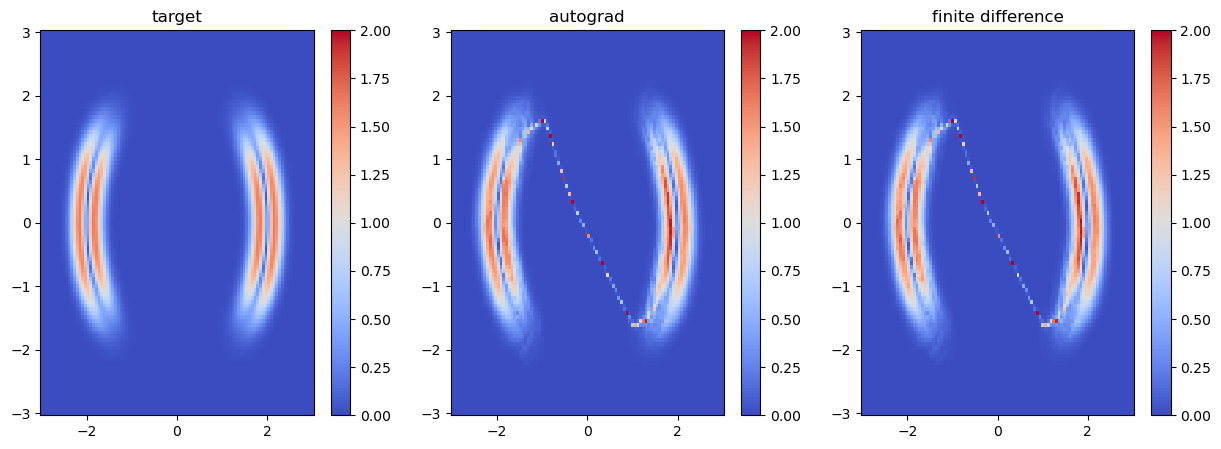

In [232]:
figs, axs = plt.subplots(1,3,figsize = (15, 5))

vmin = 0
vmax = 2

grad_fd_target_plot = torch.sqrt(grad_fd_target[:, :, 0] ** 2 + grad_fd_target[:, :, 1] ** 2)
grad_fd_target_plot[torch.isnan(grad_fd_target_plot)] = 0

grad_autograd_plot = torch.sqrt(grad_autograd[:, :, 0] ** 2 + grad_autograd[:, :, 1] ** 2)
grad_autograd_plot[torch.isnan(grad_autograd_plot)] = 0

grad_fd_plot = torch.sqrt(grad_fd[:, :, 0] ** 2 + grad_fd[:, :, 1] ** 2)
grad_fd_plot[torch.isnan(grad_fd_plot)] = 0

im0 = axs[0].pcolormesh(xx, yy, grad_fd_target_plot.detach().numpy(), cmap='coolwarm', vmin = vmin, vmax = vmax)
axs[0].set_title('target')
plt.colorbar(im0)

im1 = axs[1].pcolormesh(xx, yy, grad_autograd_plot, cmap='coolwarm', vmin = vmin, vmax = vmax)
axs[1].set_title('autograd')
plt.colorbar(im1)

im2 = axs[2].pcolormesh(xx, yy, grad_fd_plot.detach().numpy(), cmap='coolwarm', vmin = vmin, vmax = vmax)
axs[2].set_title('finite difference')
plt.colorbar(im2)